# HumMobCov — Transition Matrices Notebook

Companion notebook to .

Computes **presence** and **transition** matrices from raw trajectories on a geohash grid and uploads results to S3.

Then provides all static / animated visualizations of the matrices.

**Sections:**
1. **Imports** — standard setup
2. **INPUT** — choose region and dataset (same as main.ipynb)
3. **COMPUTE** — run the transition pipeline
4. **VISUALIZATION** — heatmaps, network plots, statistical summaries, animations


---
## 0 · Imports

In [1]:
import gc
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent   # HumMobCov/
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import (
    PROJECT_ROOT,
    PERIOD_NAMES, PERIOD_DIVISION, PERIOD_NAMES_TO_DIVISION,
    LIST_REGIONS,
    DataSet_California, DataSet_Massachusets,
)
from src.constants import (
    DIR_MILESTONES_SERVER,
    S3_ENDPOINT_URL, S3_BUCKET, S3_RAW_PREFIX, DIR_SHARD_TEMP,
    S3_OUTPUT_BUCKET, S3_OUTPUT_PREFIX,
    S3_TRANSITION_PREFIX,
)
from src.transition_matrices import TransitionPipeline
import matplotlib.pyplot as plt

print('Project root:', PROJECT_ROOT)
print('S3 endpoint: ', S3_ENDPOINT_URL)
print('Raw bucket:  ', S3_BUCKET)
print('Out bucket:  ', S3_OUTPUT_BUCKET)


Project root: /home/aamaduzzi/HumMobCov
S3 endpoint:  https://s3.atlas.fbk.eu
Raw bucket:   chub-datalake
Out bucket:   chub-datalake


---
## 1 · INPUT

**Edit this cell** to choose which region to analyse and set compute parameters.


In [2]:
# ─── Choose region ──────────────────────────────────────────────────────────
# Options: "CA"  (California)  or  "MA"  (Massachusetts)
REGION = "CA"

assert REGION in LIST_REGIONS, f"Unknown region '{REGION}'. Choose from {LIST_REGIONS}"

In [3]:
# ─── Optional parameter overrides ───────────────────────────────────────────
# Leave as None to use the defaults from constants.py

OVERRIDE_NP_            = None   # e.g. 30  (minimum stops per user per period)
OVERRIDE_T_THRESHOLD    = None   # e.g. 2   (minimum hours between stops)
OVERRIDE_OUTPUT_DIR     = None   # e.g. Path('/my/custom/output')
OVERRIDE_CONFIG_DIR     = None   # e.g. Path('/my/configs')

In [4]:
# ─── Initialise dataset ─────────────────────────────────────────────────────
if REGION == "CA":
    dataset = DataSet_California()
elif REGION == "MA":
    dataset = DataSet_Massachusets()

# Apply overrides
if OVERRIDE_NP_ is not None:
    dataset.np_ = OVERRIDE_NP_
if OVERRIDE_T_THRESHOLD is not None:
    dataset.t_threshold = OVERRIDE_T_THRESHOLD

print(f"Region:              {dataset.id_}")
print(f"Min points (np_):    {dataset.np_}")
print(f"Time threshold (h):  {dataset.t_threshold}")
print(f"Output directory:    {dataset.dir_output}")
print(f"Number of raw files: {len(dataset.dir_files)}")

Region:              CA
Min points (np_):    20
Time threshold (h):  1
Output directory:    /home/aamaduzzi/HumMobCov/milestones_analysis/CA/dataxuser
Number of raw files: 0


In [5]:
# ─── Preview time periods ────────────────────────────────────────────────────
print("Analysis periods:")
for name, (start, end) in PERIOD_NAMES_TO_DIVISION.items():
    print(f"  {name:25s}  {start.date()}  →  {end.date()}")

Analysis periods:
  15 jan - 15 march          2020-01-15  →  2020-03-15
  15 march - 15 may          2020-03-15  →  2020-05-15
  15 may - sept              2020-05-15  →  2020-09-30


---
## 2 · COMPUTE — Transition matrices (geohash grid)

Processes raw trajectories shard-by-shard from S3 — one shard at a time, so
memory usage stays constant regardless of dataset size.  For each shard:

1. Download the shard to a temp file
2. Filter rows to the period date range
3. Coarsen geohash to `GEOHASH_PRECISION` characters
4. Bin time into `DELTA_TIME_H`-hour intervals
5. Accumulate raw **presence** and **transition** counts
6. Delete the raw temp file immediately

After all shards are done, probabilities are added and the final matrices
are uploaded to S3.  Each period is independently resumable via a local
checkpoint file.

**Output location:**
```
s3://chub-datalake/final_pipeline/{REGION}/transition_matrices/
    presence_prec4_dh1.0_<period>.parquet
    transition_prec4_dh1.0_<period>.parquet
    cache_index.json
```


In [5]:
from src.constants import S3_TRANSITION_PREFIX

# ─── Compute parameters ───────────────────────────────────────────────────────
# Precision 4 → ~39km × 20km cells — lighter, good for full-region overview
# Precision 5 → ~5km × 5km cells   — finer, requires more memory
GEOHASH_PRECISION = 4
DELTA_TIME_H      = 1.0    # time-bin width in hours

print(f"Output prefix : s3://{S3_OUTPUT_BUCKET}/{S3_TRANSITION_PREFIX[REGION]}")
print(f"Raw source    : s3://{S3_BUCKET}/{S3_RAW_PREFIX[REGION]}")
print(f"Geohash prec. : {GEOHASH_PRECISION}")
print(f"Delta time    : {DELTA_TIME_H} h")


Output prefix : s3://chub-datalake/final_pipeline/CA/transition_matrices
Raw source    : s3://chub-datalake/shared/cuebiq/MOBS/urban_rural_flow_stops_cali_urban_rural_v3
Geohash prec. : 4
Delta time    : 1.0 h


In [6]:
# ─── Initialise transition pipeline ─────────────────────────────────────────
# raw_bucket / raw_s3_prefix tell the pipeline to stream raw shards from S3
# one at a time and accumulate counts incrementally — no large local disk
# required.  Each shard is downloaded, processed, and deleted before the next
# one starts.  The final matrices are uploaded to the output bucket.
tm_pipeline = TransitionPipeline(
    dataset           = dataset,
    geohash_precision = GEOHASH_PRECISION,
    delta_time_h      = DELTA_TIME_H,
    # ── output location ────────────────────────────────────────────────
    endpoint_url      = S3_ENDPOINT_URL,
    bucket            = S3_OUTPUT_BUCKET,
    s3_prefix         = S3_TRANSITION_PREFIX[REGION],
    # ── raw input source (S3-progressive mode) ─────────────────────────
    raw_bucket        = S3_BUCKET,
    raw_s3_prefix     = S3_RAW_PREFIX[REGION],
    raw_endpoint_url  = S3_ENDPOINT_URL,
    # ── local scratch ──────────────────────────────────────────────────
    temp_dir          = None,     # /tmp/humobcov_transitions by default
    keep_local        = False,    # delete temp files after successful upload
)

# ─── Show cache status (what is already on S3) ───────────────────────────────
tm_pipeline.summary()


TransitionPipeline
  Region          : CA
  Geohash prec.   : 4
  Delta time (h)  : 1.0
  Output S3       : s3://chub-datalake/final_pipeline/CA/transition_matrices
  Raw S3 source   : s3://chub-datalake/shared/cuebiq/MOBS/urban_rural_flow_stops_cali_urban_rural_v3
  Computed entries: 6
    ✓  15_jan_-_15_march_prec4_dh1.0_presence
    ✓  15_jan_-_15_march_prec4_dh1.0_transition
    ✓  15_march_-_15_may_prec4_dh1.0_presence
    ✓  15_march_-_15_may_prec4_dh1.0_transition
    ✓  15_may_-_sept_prec4_dh1.0_presence
    ✓  15_may_-_sept_prec4_dh1.0_transition


In [ ]:
# ─── Run all periods ─────────────────────────────────────────────────────────
# Resume-safe: already-computed periods are skipped.
# Data flows: memory → temp parquet → S3 → delete local.
# Set force=True to recompute even if cached.

results = tm_pipeline.run_all_periods(force=False, verbose=True)

print("\nTransition matrix run summary:")
for period, kinds in results.items():
    for kind, ok in kinds.items():
        status = "✓" if ok else "✗ (temp file kept locally)"
        print(f"  {status}  {period:25s}  {kind}")


done.
  [53/54] part-00000-47577f53-1849-4bc2-9454-22360645354c-c000.snappy.parquet … done.
  [54/54] part-00000-4b31187b-4b5d-4d70-8a5f-c29b5db630e2-c000.snappy.parquet … done.
  Accumulated 4,530,768 presence rows and 5,386,669 transition rows.
  Finalising presence matrix …
  presence_prec4_dh1.0_15_may_-_sept.parquet (19.7 MB)
  → s3://chub-datalake/final_pipeline/CA/transition_matrices/presence_prec4_dh1.0_15_may_-_sept.parquet … OK
  Finalising transition matrix …
  transition_prec4_dh1.0_15_may_-_sept.parquet (27.9 MB)
  → s3://chub-datalake/final_pipeline/CA/transition_matrices/transition_prec4_dh1.0_15_may_-_sept.parquet … OK

Transition matrix run summary:
  ✓  15 jan - 15 march          presence
  ✓  15 jan - 15 march          transition
  ✓  15 march - 15 may          presence
  ✓  15 march - 15 may          transition
  ✓  15 may - sept              presence
  ✓  15 may - sept              transition


---
## 3 · VISUALIZATION

All plots read from S3 — run Section 2 first.


### 6.1 · Load a period for plotting

In [7]:
# Pick any period to visualise
PLOT_PERIOD = dataset.period_names[0]

pres_df  = tm_pipeline.read_from_s3(PLOT_PERIOD, "presence")
trans_df = tm_pipeline.read_from_s3(PLOT_PERIOD, "transition")

print(f"Presence rows : {pres_df.height:,}")
print(f"Transition rows: {trans_df.height:,}")
print(pres_df.head(3))


Presence rows : 1,983,998
Transition rows: 2,782,328
shape: (3, 8)
┌─────────┬──────────┬─────────────┬─────────────┬─────────────┬─────────────┬───────┬─────────────┐
│ geohash ┆ time_int ┆ datetime    ┆ count_birth ┆ count_death ┆ count_trans ┆ count ┆ probability │
│ ---     ┆ ---      ┆ ---         ┆ ---         ┆ ---         ┆ it          ┆ ---   ┆ ---         │
│ str     ┆ i64      ┆ str         ┆ u32         ┆ u32         ┆ ---         ┆ u32   ┆ f64         │
│         ┆          ┆             ┆             ┆             ┆ u32         ┆       ┆             │
╞═════════╪══════════╪═════════════╪═════════════╪═════════════╪═════════════╪═══════╪═════════════╡
│ 87yk    ┆ 0        ┆ 2020-01-15T ┆ 2           ┆ 0           ┆ 0           ┆ 2     ┆ 0.0         │
│         ┆          ┆ 00:00:00    ┆             ┆             ┆             ┆       ┆             │
│ 87ym    ┆ 0        ┆ 2020-01-15T ┆ 1           ┆ 0           ┆ 1           ┆ 2     ┆ 0.000011    │
│         ┆          ┆ 0

### 6.2 · Grid heatmaps

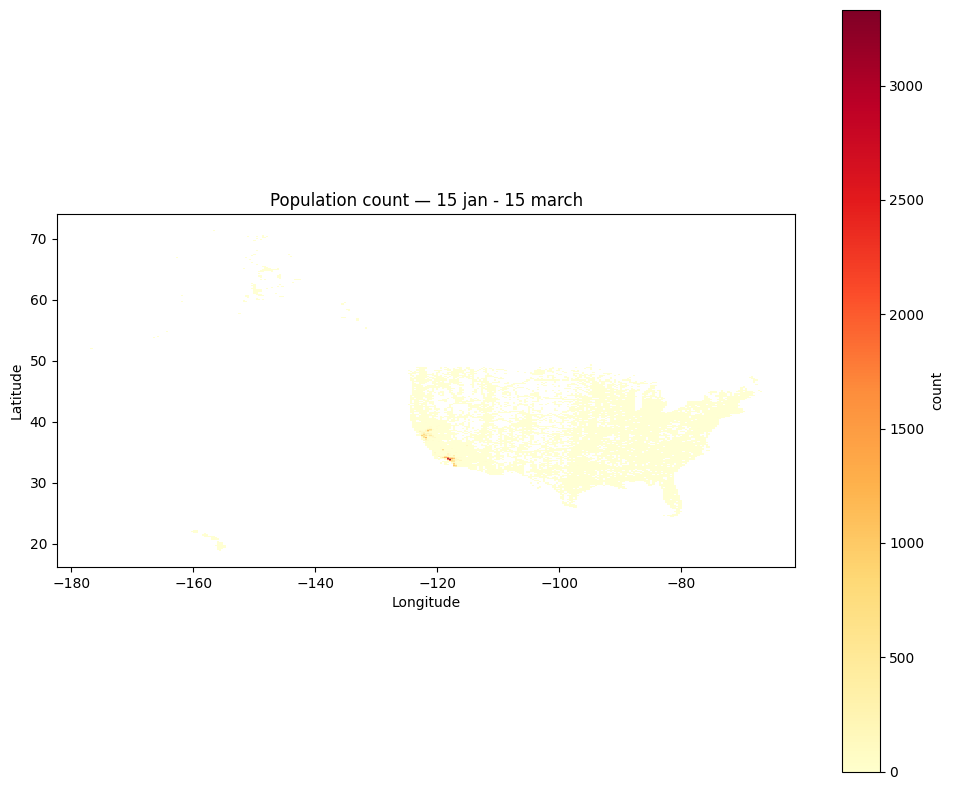

In [10]:
from src.visualization.visualization_grid_transitions import (
    plot_grid_heatmap, plot_grid_network,
)

# Heatmap of total presence count (mean across all bins)
fig, ax = plot_grid_heatmap(pres_df, "count", title=f"Population count — {PLOT_PERIOD}")
plt.show()


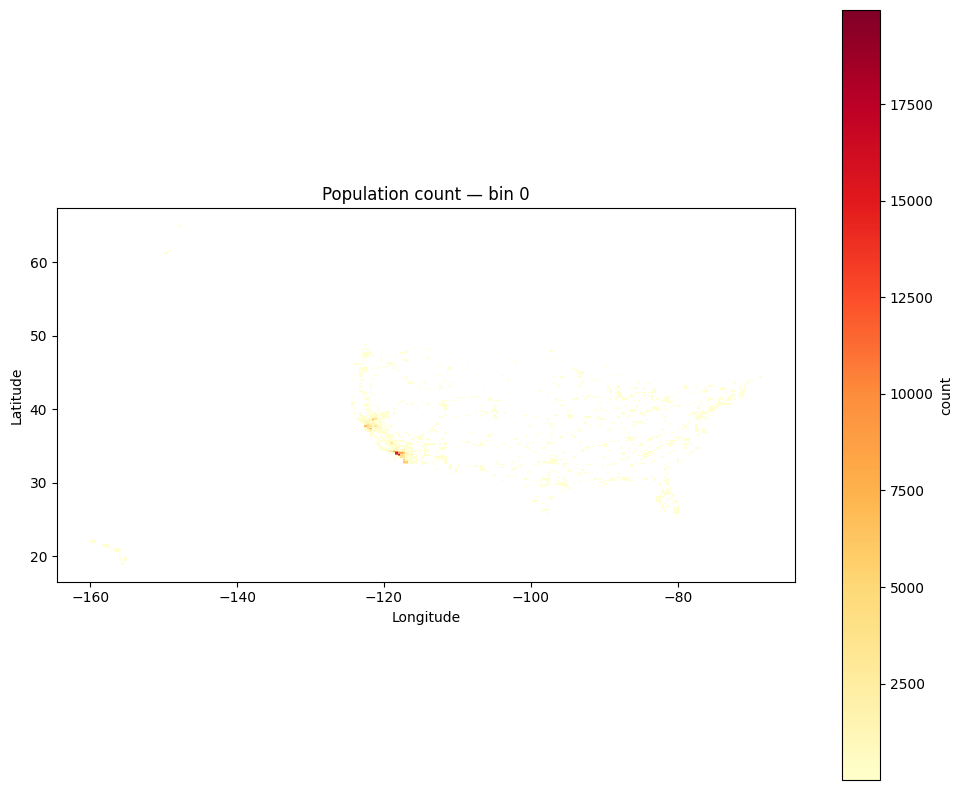

In [11]:
# Heatmap of a specific time bin — change time_int to explore
PLOT_BIN = 0
fig, ax = plot_grid_heatmap(
    pres_df, "count",
    time_int=PLOT_BIN,
    title=f"Population count — bin {PLOT_BIN}",
)
plt.show()


### 6.3 · Transition network

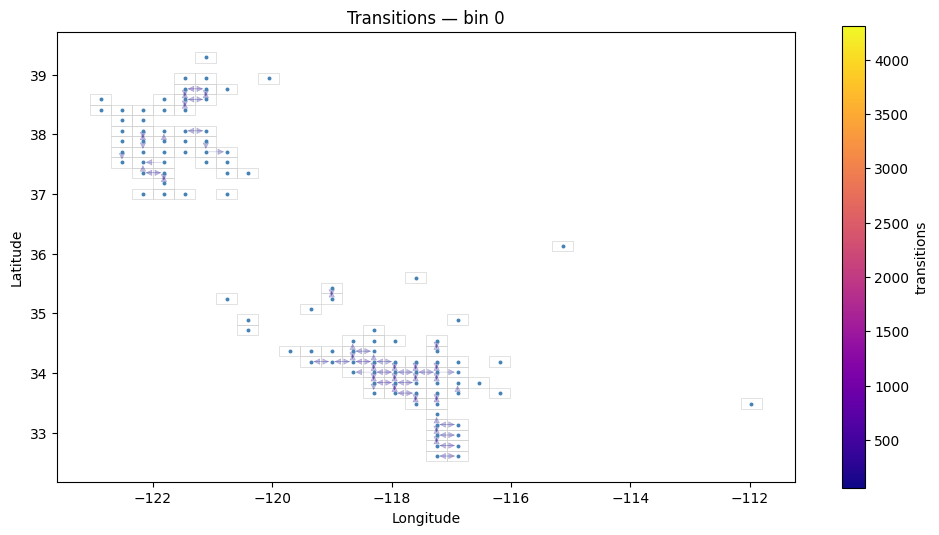

In [12]:
# Directed edge network for a single time bin (top 200 edges)
fig, ax = plot_grid_network(
    trans_df, "transitions",
    time_int=PLOT_BIN,
    top_n=200,
    title=f"Transitions — bin {PLOT_BIN}",
)
plt.show()


### 6.4 · Statistical summaries

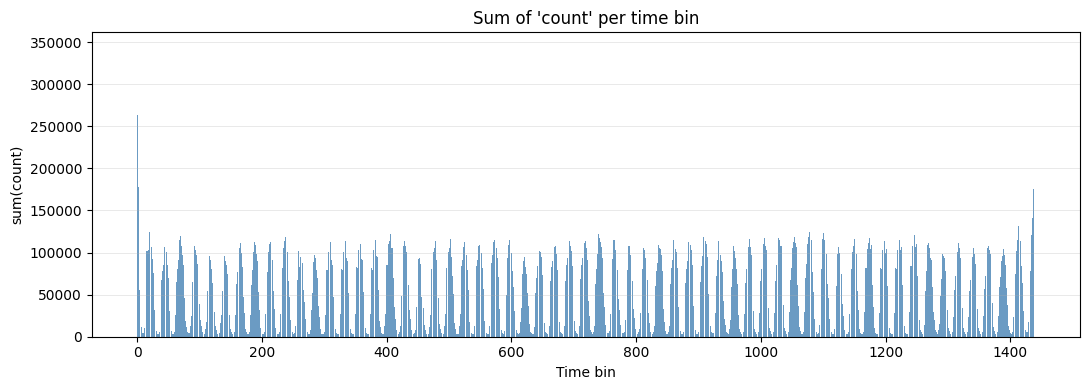

In [13]:
from src.visualization.visualization_transition_statistics import (
    plot_population_over_time,
    plot_population_distribution,
    plot_mean_transitions_over_time,
    plot_transition_distribution,
    plot_top_transitions,
    plot_top_populated_stochastic,
)

# Total population per time bin
fig, ax = plot_population_over_time(pres_df, "count")
plt.show()


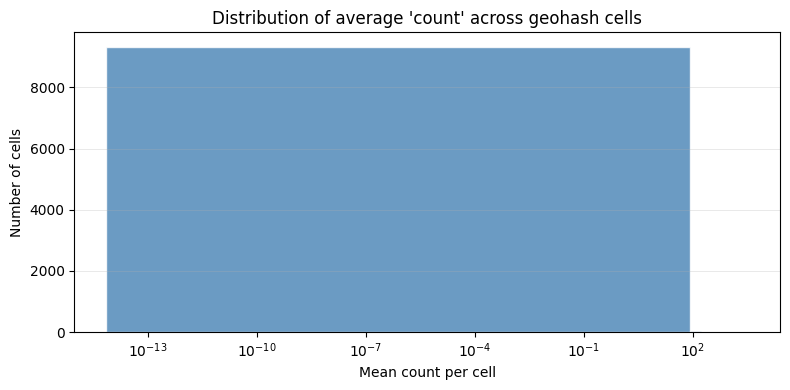

In [14]:
# Distribution of average cell population
fig, ax = plot_population_distribution(pres_df, "count", log_scale=True)
plt.show()


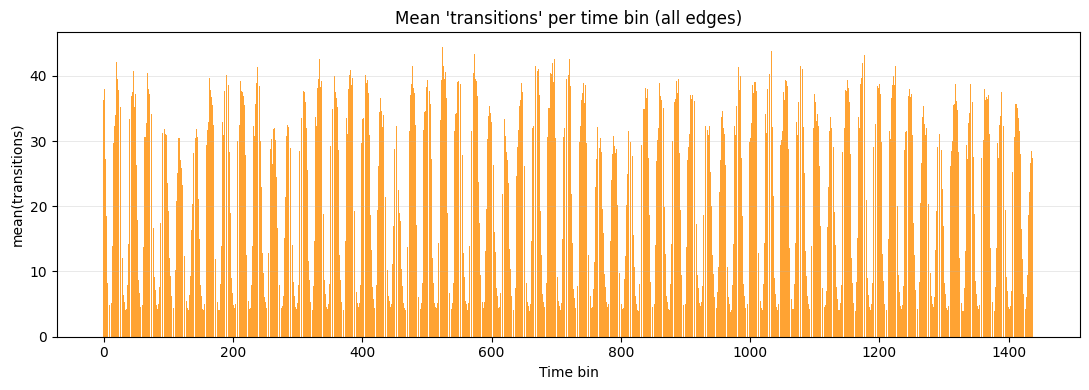

In [15]:
# Average transitions per time bin
fig, ax = plot_mean_transitions_over_time(trans_df, "transitions")
plt.show()


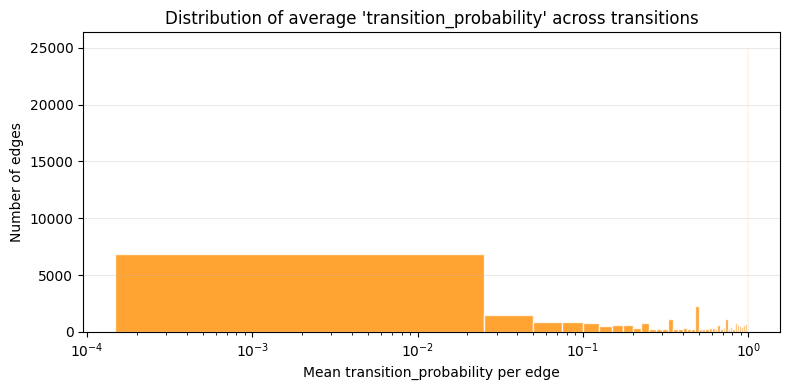

In [16]:
# Distribution of transition weights
fig, ax = plot_transition_distribution(trans_df, "transition_probability", log_scale=True)
plt.show()


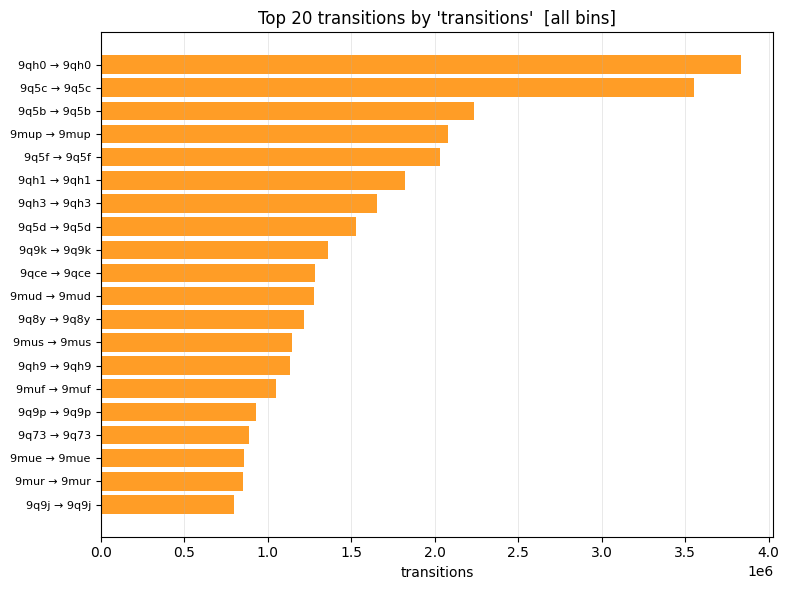

In [17]:
# Top-N edges by total transitions
fig, ax = plot_top_transitions(trans_df, n=20)
plt.show()


### 6.5 · Top populated cells as stochastic processes

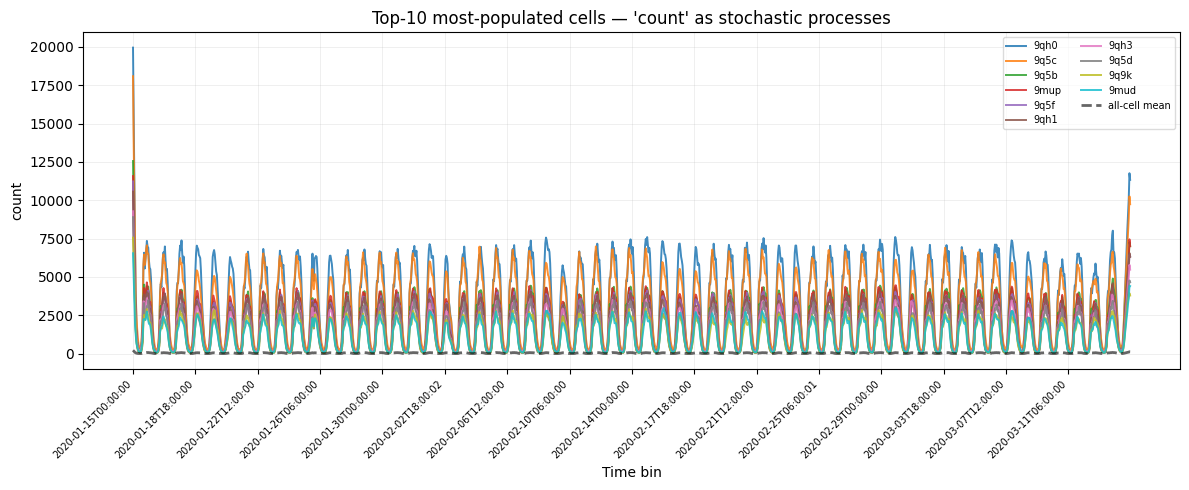

In [18]:
# Time series of the top-N busiest geohash cells.
# Each coloured line is one cell treated as a stochastic process.
# The dashed black line shows the overall mean across all cells.
fig, ax = plot_top_populated_stochastic(
    pres_df,
    col="count",
    n=10,
    show_mean=True,
)
plt.show()


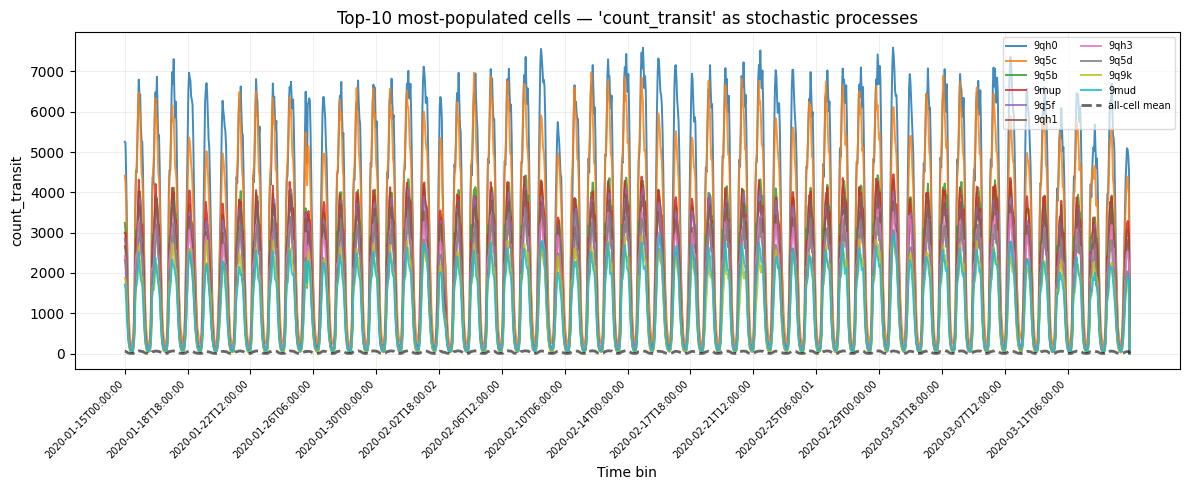

In [19]:
# Same for transit counts (users moving through each cell)
fig, ax = plot_top_populated_stochastic(
    pres_df,
    col="count_transit",
    n=10,
    show_mean=True,
)
plt.show()


### 6.6 · Animated grid heatmap

In [ ]:
from IPython.display import HTML
from src.visualization.animation_grid_transitions import (
    animate_grid_heatmap, animate_grid_network,
)

anim = animate_grid_heatmap(
    pres_df, "count",
    fps=3,
    vmin=0,
    vmax=pres_df["count"].quantile(0.99),
    title_prefix=f"{REGION} — {PLOT_PERIOD}",
)
HTML(anim.to_jshtml())


Animation size has reached 21015663 bytes, exceeding the limit of 20971520.0. If you're sure you want a larger animation embedded, set the animation.embed_limit rc parameter to a larger value (in MB). This and further frames will be dropped.


### 6.7 · Animated transition network

In [ ]:
anim_net = animate_grid_network(
    trans_df, "transitions",
    fps=3,
    top_n=200,
    title_prefix=f"{REGION} — {PLOT_PERIOD}",
)
HTML(anim_net.to_jshtml())


### 6.8 · Animated statistical distributions

In [ ]:
from src.visualization.animation_transition_statistics import (
    animate_transition_distribution,
    animate_weight_evolution,
    animate_population_distribution,
)

# Evolution of the distribution of transition counts
anim_td = animate_transition_distribution(
    trans_df, "transitions",
    fps=3, log_scale=True,
    fixed_xlim=(1, trans_df["transitions"].max()),
)
HTML(anim_td.to_jshtml())


In [ ]:
# Evolution of transition probability weights
anim_w = animate_weight_evolution(trans_df, fps=3)
HTML(anim_w.to_jshtml())


In [ ]:
# Evolution of the population distribution across cells
anim_pop = animate_population_distribution(
    pres_df, "count",
    fps=3, log_scale=True,
)
HTML(anim_pop.to_jshtml())


---
## 7 · Distribution pipeline — all three periods

Loads all three presence/transition matrices from S3 and computes the
per-time-bin histogram distributions using
`compute_presence_distribution` / `compute_transition_distribution`.

Each row of the resulting DataFrames represents one histogram bin for one
time bin.  With 100 bins and T time bins per period, each DataFrame has
`T × 100` rows.  Columns:

| Column | dtype | Meaning |
|--------|-------|---------|
| `time_bin` | Int64 | time bin index |
| `period_observation` | Utf8 | e.g. `"15 jan - 15 march"` |
| `bin_{col}` | Float64 | left edge of the histogram bin |
| `count_{col}` | Int64 | number of cells / edges in that bin |


In [8]:
from src.transition_matrices.distribution_transitions_and_presences import (
    compute_presence_distribution,
    compute_transition_distribution,
    PRESENCE_COLS,
    TRANSITION_COLS,
)
from src.visualization.visualization_distribution_transition_counts import (
    plot_period_aggregate_distribution,
    plot_all_columns_for_period,
    animate_distribution_evolution,
)

# ── Load all three periods from S3 ───────────────────────────────────────────
print("Loading all periods from S3 …")
all_pres: dict[str, object]  = {}
all_trans: dict[str, object] = {}

for period in dataset.period_names:
    print(f"  {period} …", end=" ", flush=True)
    all_pres[period]  = tm_pipeline.read_from_s3(period, "presence")
    all_trans[period] = tm_pipeline.read_from_s3(period, "transition")
    print(f"presence={all_pres[period].height:,} rows, "
          f"transition={all_trans[period].height:,} rows")

print("\nDone.")


Loading all periods from S3 …
  15 jan - 15 march … presence=1,983,998 rows, transition=2,782,328 rows
  15 march - 15 may … presence=1,529,471 rows, transition=2,042,816 rows
  15 may - sept … presence=4,530,768 rows, transition=5,386,669 rows

Done.


In [9]:
import polars as pl

# ── Compute distributions for each period (100 bins each) ────────────────────
DIST_BINS = 100

print("Computing presence distributions …")
pres_dists  = [
    compute_presence_distribution(all_pres[p],  p, bins=DIST_BINS)
    for p in dataset.period_names
]
all_pres_dist  = pl.concat(pres_dists,  how="vertical_relaxed")

print("Computing transition distributions …")
trans_dists = [
    compute_transition_distribution(all_trans[p], p, bins=DIST_BINS)
    for p in dataset.period_names
]
all_trans_dist = pl.concat(trans_dists, how="vertical_relaxed")

print(f"\nPresence distribution  : {all_pres_dist.shape}  cols={all_pres_dist.columns}")
print(f"Transition distribution: {all_trans_dist.shape}  cols={all_trans_dist.columns}")


Computing presence distributions …
Computing transition distributions …

Presence distribution  : (585600, 12)  cols=['time_bin', 'period_observation', 'bin_count_birth', 'count_count_birth', 'bin_count_death', 'count_count_death', 'bin_count_transit', 'count_count_transit', 'bin_count', 'count_count', 'bin_probability', 'count_probability']
Transition distribution: (585300, 6)  cols=['time_bin', 'period_observation', 'bin_transitions', 'count_transitions', 'bin_transition_probability', 'count_transition_probability']


---
### 7.1 · Period-aggregate distributions — Presence columns

Each step curve shows the mean `count_{col}` across all time bins for one period.
This is $\bar{X}^{(c)}_P$ — the average distribution shape per observation phase.


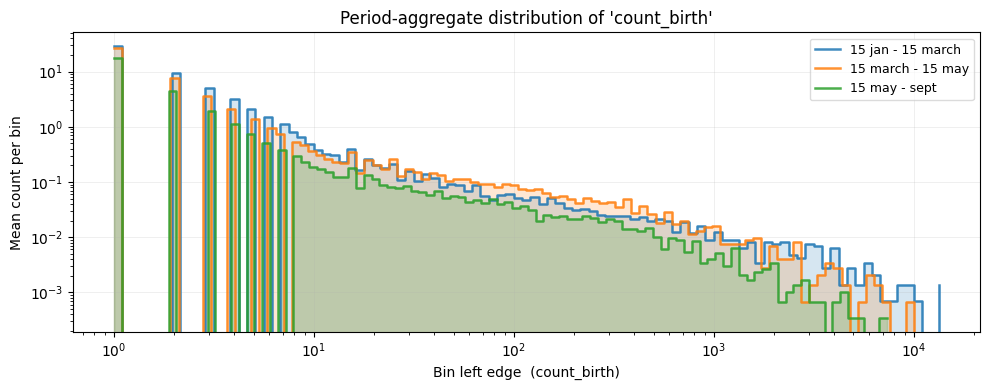

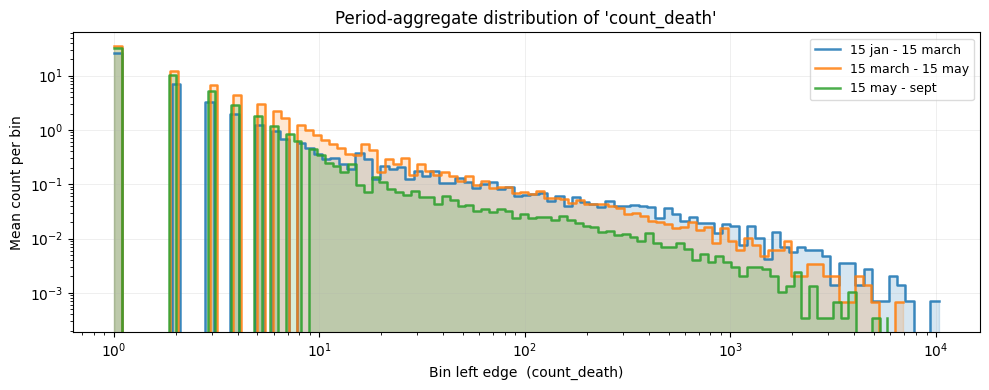

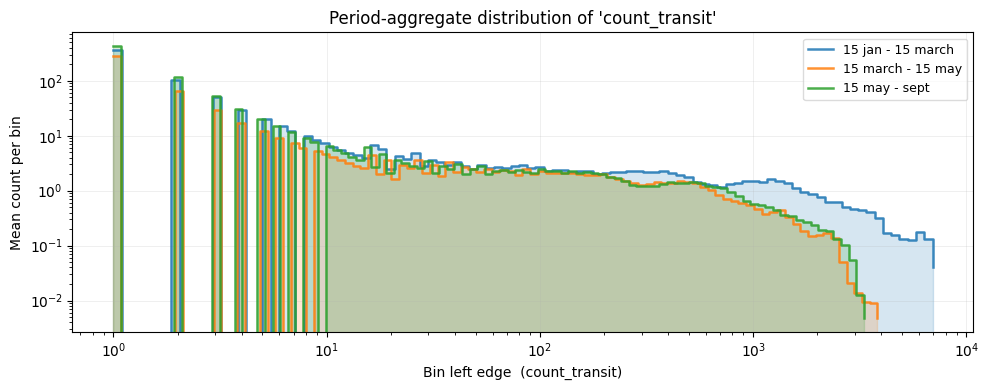

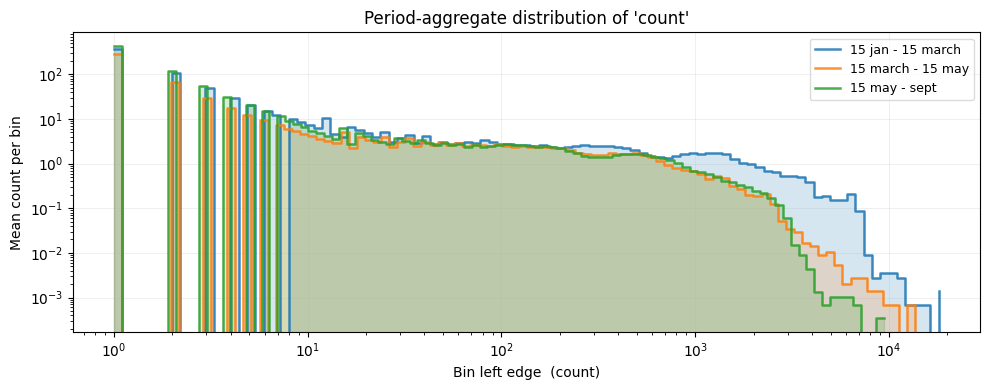

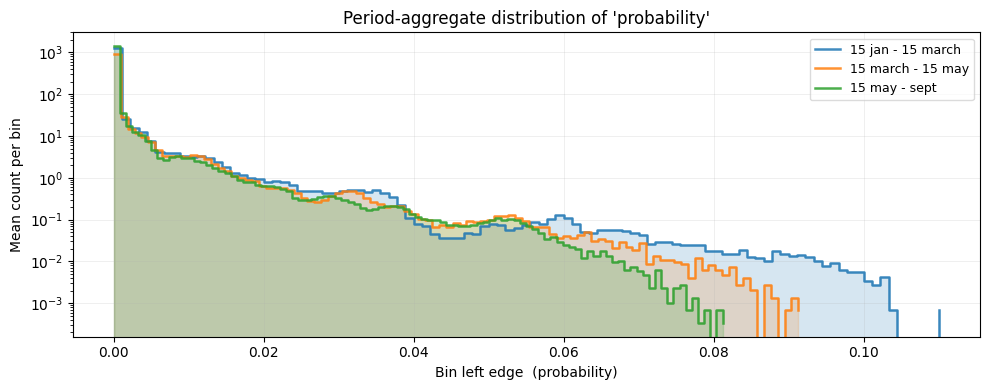

In [10]:
for col in PRESENCE_COLS:
    fig, ax = plot_period_aggregate_distribution(
        all_pres_dist, col, log_x=(col != "probability"), log_y=True,
    )
    plt.show()


---
### 7.2 · Period-aggregate distributions — Transition columns


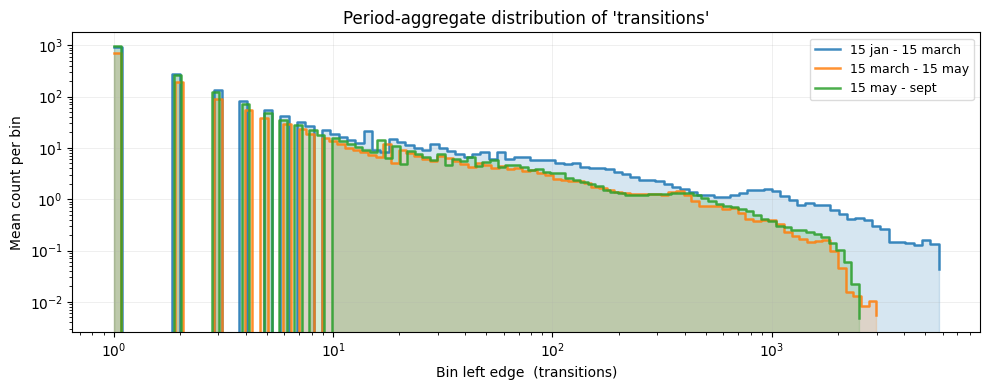

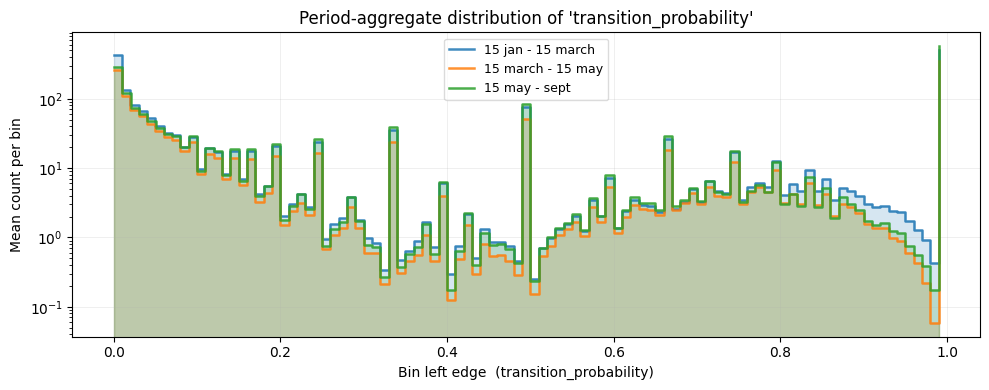

In [11]:
for col in TRANSITION_COLS:
    fig, ax = plot_period_aggregate_distribution(
        all_trans_dist, col, log_x=(col == "transitions"), log_y=True,
    )
    plt.show()


---
### 7.3 · All presence columns per period (grid view)


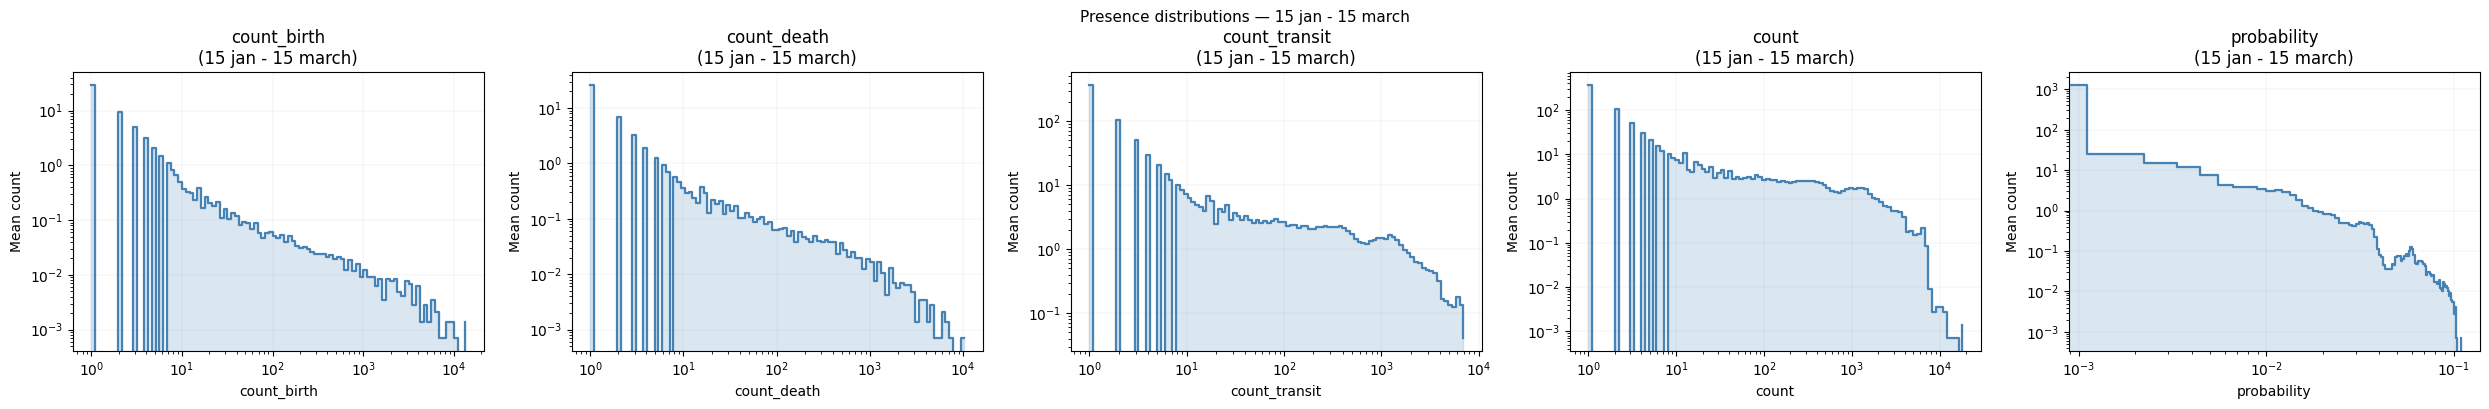

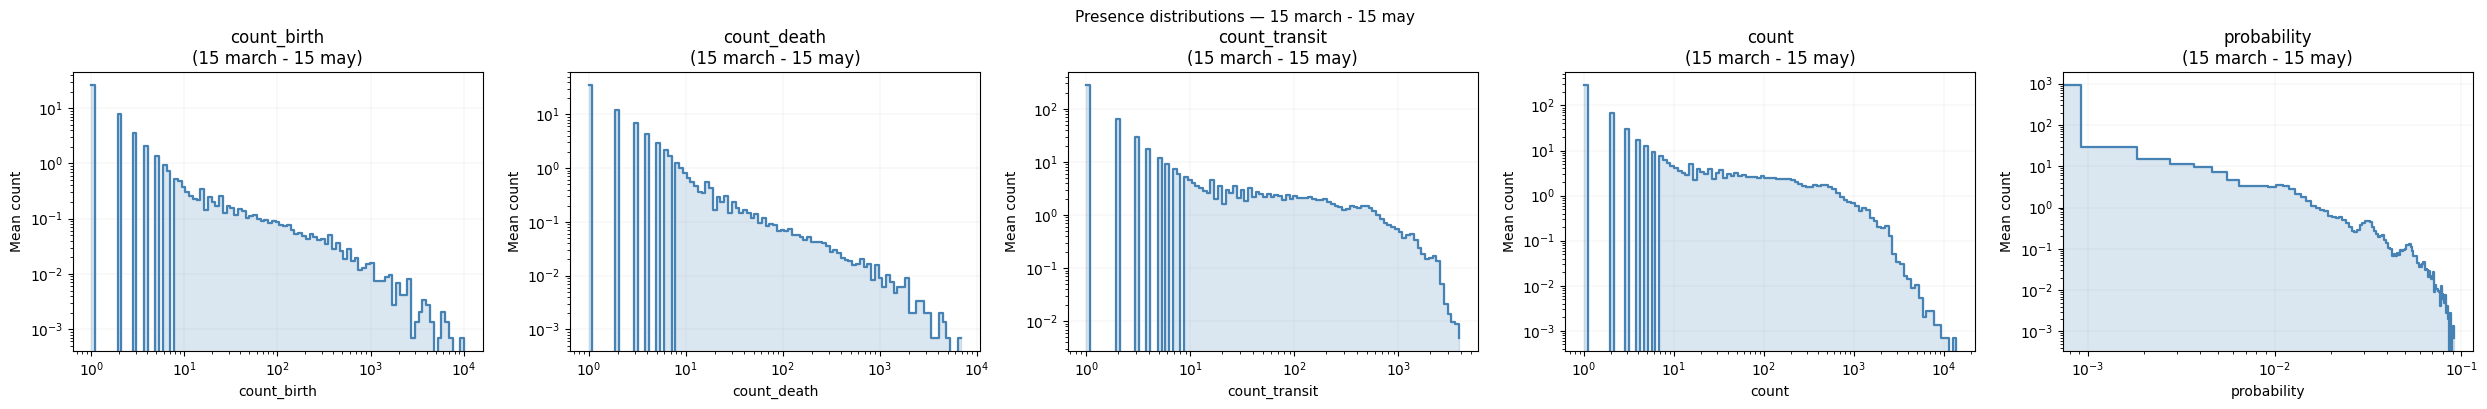

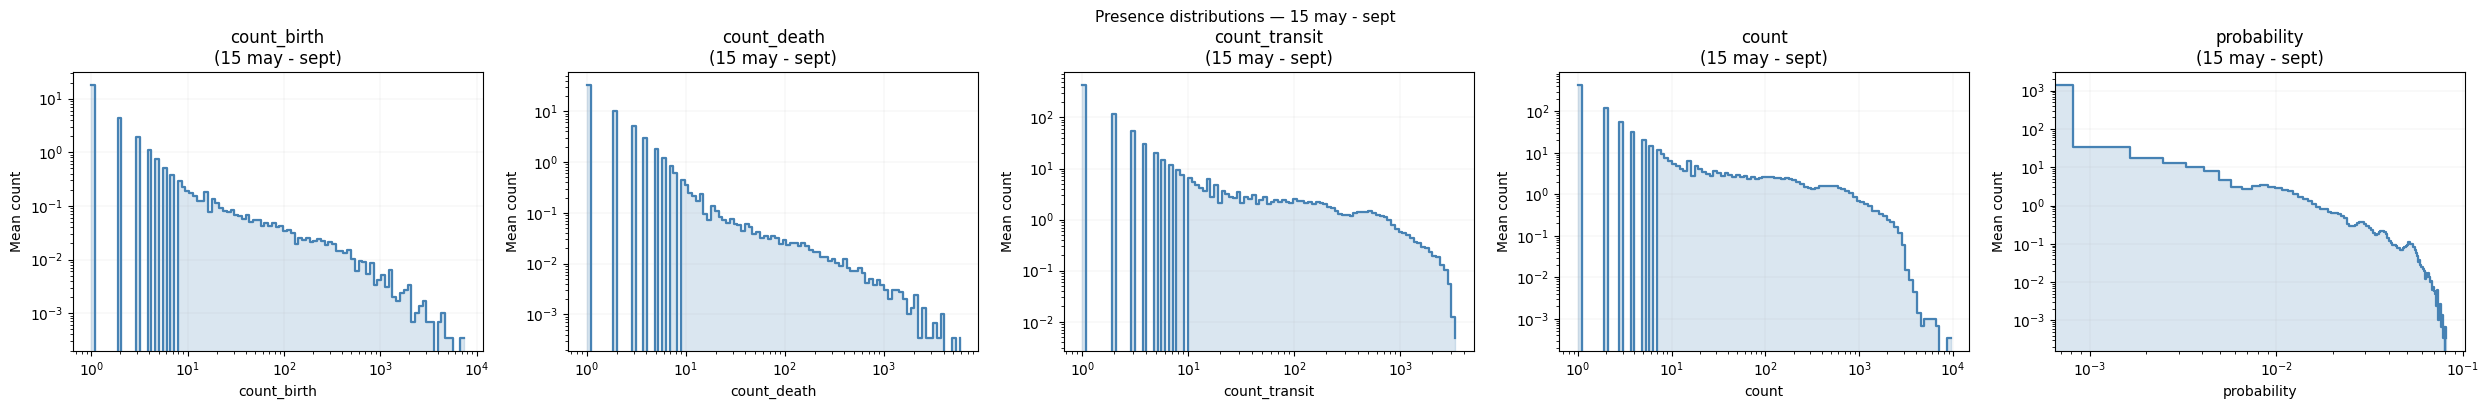

In [12]:
for period in dataset.period_names:
    fig, axes = plot_all_columns_for_period(
        all_pres_dist, period, PRESENCE_COLS,
        log_x=True, log_y=True,
    )
    fig.suptitle(f"Presence distributions — {period}", y=1.01, fontsize=11)
    plt.show()


---
### 7.4 · Animated distribution evolution — Presence columns

Each frame = one time bin.  Bars = instantaneous distribution $X^{(c)}_t$.
Solid black line = centred moving average $\widetilde{X}^{(c)}_t$ (window = 5 bins).
One sub-plot per period so all three phases are compared side-by-side.


In [ ]:
from IPython.display import HTML

for col in PRESENCE_COLS:
    anim = animate_distribution_evolution(
        all_pres_dist, col,
        fps=4, window=5,
        log_x=(col != "probability"), log_y=False,
        title_prefix=f"Presence — {REGION}",
        max_frames=100,
    )
    display(HTML(f"<h4>{col}</h4>"))
    display(HTML(anim.to_jshtml()))
    plt.close("all")


---
### 7.5 · Animated distribution evolution — Transition columns


In [ ]:
for col in TRANSITION_COLS:
    anim = animate_distribution_evolution(
        all_trans_dist, col,
        fps=4, window=5,
        log_x=(col == "transitions"), log_y=False,
        title_prefix=f"Transition — {REGION}",
        max_frames=100,
    )
    display(HTML(f"<h4>{col}</h4>"))
    display(HTML(anim.to_jshtml()))
    plt.close("all")
